### imagelag 模型拟合

拟合lag model

DC-peak=Nt​(1−e^(−DC/Qc​))

Nt:陷阱深度 
Qc:陷阱半饱和信号强度(填充陷阱的大小)

拟合结果: f(Q) = Q - peak = Nt * (1 - exp(-Q/Qc))
  Nt  = 62.63 ± 1.00 DN  (陷阱容量上限)
  Qc  = 85.4 ± 4.1 DN  (特征信号强度)
  R²  = 0.99564
  RMS = 1.085 DN

       Q      peak      Q-peak       f_fit     resid      rel%
   33.32     11.79      21.530      20.232     1.298     6.03%
   35.28     13.19      22.090      21.194     0.896     4.05%
   48.71     20.86      27.850      27.224     0.626     2.25%
  101.98     60.36      41.620      43.655    -2.035    -4.89%
  218.43    160.95      57.480      57.777    -0.297    -0.52%
  223.47    166.01      57.460      58.055    -0.595    -1.04%
  236.24    177.66      58.580      58.691    -0.111    -0.19%
  305.86    243.58      62.280      60.887     1.393     2.24%

外推 Q=946.25 DN, peak=847.00 DN → 实测 Q-peak=99.25 DN
模型预测 f(Q) = 62.63 DN
偏差 37% → 饱和点已偏离模型


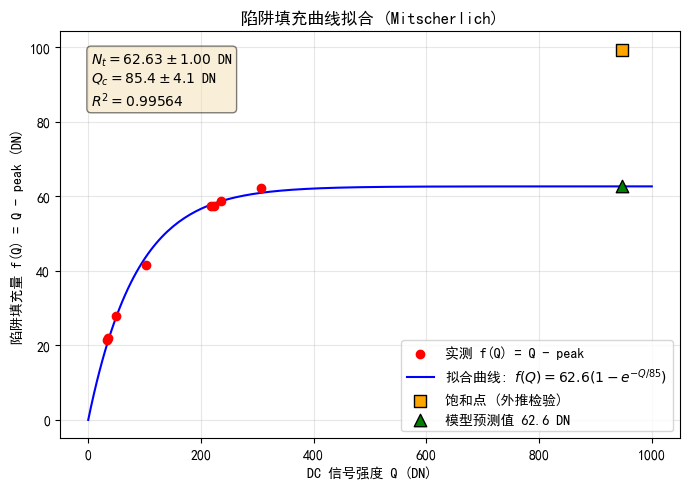

In [34]:
"""
陷阱型 Image Lag 模型拟合与验证（基于 Q - peak）
=================================================
模型: f(Q) = Q - peak = Nt * (1 - exp(-Q / Qc))
输入: Q, peak (脉冲响应峰值)
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ------------------------------------------------------------------
# 1. 数据 (去掉 946DN 饱和点)
# ------------------------------------------------------------------
data = [
    # Q(DN)    peak(DN)  (lag1 仅作参考，不参与拟合)
    ( 33.32,   11.79  ),
    ( 35.28,   13.19  ),
    ( 48.71,   20.86  ),
    (101.98,   60.36  ),
    (218.43,  160.95  ),
    (223.47,  166.01  ),
    (236.24,  177.66  ),
    (305.86,  243.58  ),
]

new_data = [
    ( 33.15,   11.38 ),
    ( 48.88,   20.72 ),
    ( 55.43,   24.54 ),
    ( 68.96,   34.04 ),
    ( 71.09,   35.00 ),
    ( 82.08,   43.38 ),
    (113.95,   67.55 ),
    (136.37,   85.84 ),
    (518.23,  431.33 ),
]



Q    = np.array([d[0] for d in data])
peak = np.array([d[1] for d in data])



# 饱和点 (外推检验)
Q_sat, peak_sat = 946.25, 847.00   # 原饱和点数据
lag1_sat = 53.00  # 仅用于对比，不参与拟合

# 计算陷阱填充量
y = Q - peak   # f(Q)

# ------------------------------------------------------------------
# 2. 模型定义
# ------------------------------------------------------------------
def f_mitscherlich(Q, Nt, Qc):
    """单陷阱 Mitscherlich 填充曲线"""
    return Nt * (1 - np.exp(-Q / Qc))

# ------------------------------------------------------------------
# 3. 拟合 (目标 y = Q - peak)
# ------------------------------------------------------------------
p0 = [40, 200]          # 初值可修改
popt, pcov = curve_fit(f_mitscherlich, Q, y, p0=p0, maxfev=10000)
Nt, Qc = popt
perr   = np.sqrt(np.diag(pcov))

y_fit     = f_mitscherlich(Q, Nt, Qc)
residuals = y - y_fit
rms       = np.sqrt(np.mean(residuals**2))
ss_res    = np.sum(residuals**2)
ss_tot    = np.sum((y - np.mean(y))**2)
r2        = 1 - ss_res / ss_tot

# ------------------------------------------------------------------
# 4. 打印拟合结果
# ------------------------------------------------------------------
print("=" * 55)
print("拟合结果: f(Q) = Q - peak = Nt * (1 - exp(-Q/Qc))")
print("=" * 55)
print(f"  Nt  = {Nt:.2f} ± {perr[0]:.2f} DN  (陷阱容量上限)")
print(f"  Qc  = {Qc:.1f} ± {perr[1]:.1f} DN  (特征信号强度)")
print(f"  R²  = {r2:.5f}")
print(f"  RMS = {rms:.3f} DN")
print()
print(f"{'Q':>8}  {'peak':>8}  {'Q-peak':>10}  {'f_fit':>10}  {'resid':>8}  {'rel%':>8}")
for i in range(len(Q)):
    print(f"{Q[i]:8.2f}  {peak[i]:8.2f}  {y[i]:10.3f}  {y_fit[i]:10.3f}  "
          f"{residuals[i]:8.3f}  {100*residuals[i]/y[i]:7.2f}%")

# 外推饱和点
pred_sat = f_mitscherlich(Q_sat, Nt, Qc)
y_sat = Q_sat - peak_sat   # 饱和点处的真实填充量
print(f"\n外推 Q={Q_sat:.2f} DN, peak={peak_sat:.2f} DN → 实测 Q-peak={y_sat:.2f} DN")
print(f"模型预测 f(Q) = {pred_sat:.2f} DN")
print(f"偏差 {100*(y_sat - pred_sat)/y_sat:.0f}% → 饱和点已偏离模型")

# ------------------------------------------------------------------
# 5. 绘图 (单图：拟合曲线)
# ------------------------------------------------------------------
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(7, 5))
Q_plot = np.linspace(0, 1000, 200)
f_plot = f_mitscherlich(Q_plot, Nt, Qc)

plt.scatter(Q, y, color='red', label='实测 f(Q) = Q - peak', zorder=5)
plt.plot(Q_plot, f_plot, 'b-', label=f'拟合曲线: $f(Q) = {Nt:.1f}(1-e^{{-Q/{Qc:.0f}}})$')

# 外推点显示
plt.scatter(Q_sat, y_sat, color='orange', s=80, marker='s',
            label='饱和点 (外推检验)', edgecolors='k', zorder=5)
plt.scatter(Q_sat, pred_sat, color='green', s=80, marker='^',
            label=f'模型预测值 {pred_sat:.1f} DN', edgecolors='k', zorder=5)

plt.xlabel('DC 信号强度 Q (DN)')
plt.ylabel('陷阱填充量 f(Q) = Q - peak (DN)')
plt.title('陷阱填充曲线拟合 (Mitscherlich)')
plt.legend()
plt.grid(alpha=0.3)

# 参数文本框
textstr = f'$N_t = {Nt:.2f} \\pm {perr[0]:.2f}$ DN\n$Q_c = {Qc:.1f} \\pm {perr[1]:.1f}$ DN\n$R^2 = {r2:.5f}$'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='top', bbox=props)

plt.tight_layout()
plt.savefig('image_lag_fit.png', dpi=150)
plt.show()

拟合结果 (基于8个训练点): f(Q) = Nt * (1 - exp(-Q/Qc))
  Nt  = 62.63 ± 1.00 DN
  Qc  = 85.4 ± 4.1 DN
  R²  = 0.99564
  RMS = 1.085 DN

验证点预测 (模型外推):
       Q      peak     实测 f(Q)     预测 f(Q)        残差       相对误差%
   33.15     11.38      21.770      20.148     1.622       7.45%
   48.88     20.72      28.160      27.294     0.866       3.07%
   55.43     24.54      30.890      29.903     0.987       3.20%
   68.96     34.04      34.920      34.698     0.222       0.64%
   71.09     35.00      36.090      35.386     0.704       1.95%
   82.08     43.38      38.700      38.676     0.024       0.06%
  113.95     67.55      46.400      46.137     0.263       0.57%
  136.37     85.84      50.530      49.945     0.585       1.16%
  518.23    431.33      86.900      62.485    24.415      28.09%


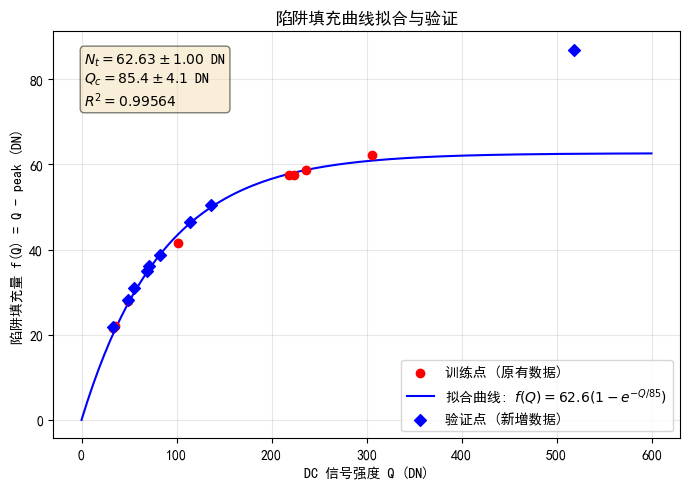

In [35]:
"""
陷阱型 Image Lag 模型拟合与验证（增加验证点散点）
=================================================
原有8点拟合 Mitscherlich 曲线，新增9点作为验证散点（不参与拟合）
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ------------------------------------------------------------------
# 1. 原有训练数据 (Q, peak)
# ------------------------------------------------------------------
train_data = [
    ( 33.32,   11.79 ),
    ( 35.28,   13.19 ),
    ( 48.71,   20.86 ),
    (101.98,   60.36 ),
    (218.43,  160.95 ),
    (223.47,  166.01 ),
    (236.24,  177.66 ),
    (305.86,  243.58 ),
]

Q_train = np.array([d[0] for d in train_data])
peak_train = np.array([d[1] for d in train_data])
y_train = Q_train - peak_train   # f(Q) 实测值

# ------------------------------------------------------------------
# 2. 新增验证数据 (Q, peak) - 仅用于散点图
# ------------------------------------------------------------------
val_data = [
    ( 33.15,   11.38 ),
    ( 48.88,   20.72 ),
    ( 55.43,   24.54 ),
    ( 68.96,   34.04 ),
    ( 71.09,   35.00 ),
    ( 82.08,   43.38 ),
    (113.95,   67.55 ),
    (136.37,   85.84 ),
    (518.23,  431.33 ),
]

Q_val = np.array([d[0] for d in val_data])
peak_val = np.array([d[1] for d in val_data])
y_val = Q_val - peak_val   # 验证点的 f(Q) 实测值

# ------------------------------------------------------------------
# 3. 模型定义与拟合 (仅基于训练集)
# ------------------------------------------------------------------
def f_mitscherlich(Q, Nt, Qc):
    return Nt * (1 - np.exp(-Q / Qc))

p0 = [40, 200]
popt, pcov = curve_fit(f_mitscherlich, Q_train, y_train, p0=p0, maxfev=10000)
Nt, Qc = popt
perr = np.sqrt(np.diag(pcov))

# 训练集上的统计
y_train_fit = f_mitscherlich(Q_train, Nt, Qc)
res_train = y_train - y_train_fit
rms_train = np.sqrt(np.mean(res_train**2))
ss_res = np.sum(res_train**2)
ss_tot = np.sum((y_train - np.mean(y_train))**2)
r2 = 1 - ss_res / ss_tot

# ------------------------------------------------------------------
# 4. 打印拟合参数及验证点预测偏差
# ------------------------------------------------------------------
print("=" * 55)
print("拟合结果 (基于8个训练点): f(Q) = Nt * (1 - exp(-Q/Qc))")
print("=" * 55)
print(f"  Nt  = {Nt:.2f} ± {perr[0]:.2f} DN")
print(f"  Qc  = {Qc:.1f} ± {perr[1]:.1f} DN")
print(f"  R²  = {r2:.5f}")
print(f"  RMS = {rms_train:.3f} DN\n")

print("验证点预测 (模型外推):")
print(f"{'Q':>8}  {'peak':>8}  {'实测 f(Q)':>10}  {'预测 f(Q)':>10}  {'残差':>8}  {'相对误差%':>10}")
for i in range(len(Q_val)):
    pred = f_mitscherlich(Q_val[i], Nt, Qc)
    resid = y_val[i] - pred
    rel_err = 100 * resid / y_val[i] if y_val[i] != 0 else np.nan
    print(f"{Q_val[i]:8.2f}  {peak_val[i]:8.2f}  {y_val[i]:10.3f}  {pred:10.3f}  {resid:8.3f}  {rel_err:9.2f}%")

# ------------------------------------------------------------------
# 5. 绘图: 只显示拟合曲线 + 训练点 + 验证点散点
# ------------------------------------------------------------------
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(7, 5))
Q_plot = np.linspace(0, 600, 200)   # 横轴范围稍微扩大以包含验证点
f_plot = f_mitscherlich(Q_plot, Nt, Qc)

# 训练点 (红色圆点)
plt.scatter(Q_train, y_train, color='red', label='训练点 (原有数据)', zorder=5)
# 拟合曲线
plt.plot(Q_plot, f_plot, 'b-', label=f'拟合曲线: $f(Q) = {Nt:.1f}(1-e^{{-Q/{Qc:.0f}}})$')
# 验证点 (蓝色菱形)
plt.scatter(Q_val, y_val, color='blue', marker='D', label='验证点 (新增数据)', zorder=5)

plt.xlabel('DC 信号强度 Q (DN)')
plt.ylabel('陷阱填充量 f(Q) = Q - peak (DN)')
plt.title('陷阱填充曲线拟合与验证')
plt.legend()
plt.grid(alpha=0.3)

# 参数文本框
textstr = f'$N_t = {Nt:.2f} \\pm {perr[0]:.2f}$ DN\n$Q_c = {Qc:.1f} \\pm {perr[1]:.1f}$ DN\n$R^2 = {r2:.5f}$'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='top', bbox=props)

plt.tight_layout()
plt.savefig('image_lag_fit_with_validation.png', dpi=150)
plt.show()

In [36]:
def f(Q, Nt, Qc):
    return Nt * (1 - np.exp(-Q / Qc))

# 示例
print(Nt)

62.63049631410832


### 拟合陷阱释放curve 拟合

### 单指数模型拟合

<>:35: SyntaxWarning: invalid escape sequence '\D'
<>:35: SyntaxWarning: invalid escape sequence '\D'
C:\Users\20250612\AppData\Local\Temp\ipykernel_48500\3041508038.py:35: SyntaxWarning: invalid escape sequence '\D'
  plt.plot(dt_fine, y_fit, 'b-', label=f'指数拟合: $y = {A:.2f} e^{{-{k:.3f} \Delta t}}$')


拟合结果: y = A * exp(-k * (t - 47))
A = 7.040 ± 12505773.613
k = 0.422 ± 0.032 (衰减率)
半衰期 t_half = 1.64 帧


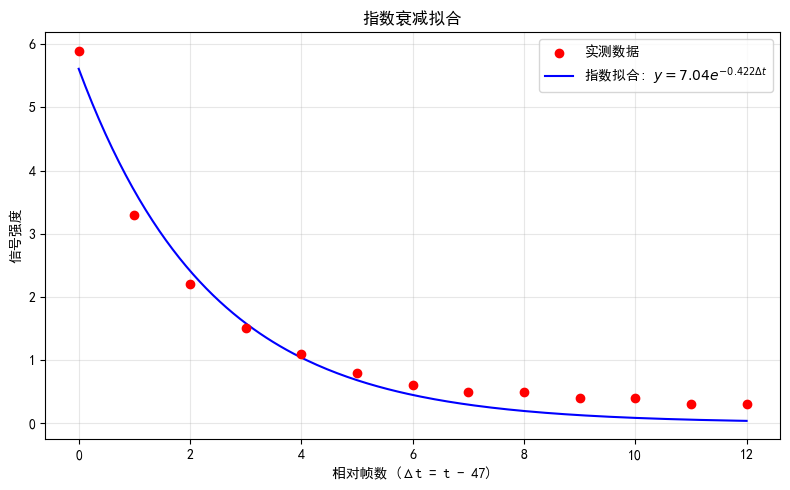

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 数据
t = np.array([ 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60])
y = np.array([5.9, 3.3, 2.2, 1.5, 1.1, 0.8, 0.6, 0.5, 0.5, 0.4, 0.4, 0.3, 0.3])

# 相对时间（第一帧为0）
dt = t - t[0]

# 定义指数模型: y = A * exp(-k * dt)
def exp_decay(dt, A, k, a):
    return A * np.exp(-k * dt+a)

# 拟合
p0 = (y[0], 0.5, 0)   # 初始猜测：振幅 A，衰减率 k，偏移 a
popt, pcov = curve_fit(exp_decay, dt, y, p0=p0)
A, k, a  = popt
perr = np.sqrt(np.diag(pcov))

# 打印结果
print("拟合结果: y = A * exp(-k * (t - 47))")
print(f"A = {A:.3f} ± {perr[0]:.3f}")
print(f"k = {k:.3f} ± {perr[1]:.3f} (衰减率)")
print(f"半衰期 t_half = {np.log(2)/k:.2f} 帧")

# 生成平滑曲线用于绘图
dt_fine = np.linspace(0, dt[-1], 200)
y_fit = exp_decay(dt_fine, A, k,a)

# 绘图
plt.figure(figsize=(8, 5))
plt.scatter(dt, y, color='red', label='实测数据', zorder=5)
plt.plot(dt_fine, y_fit, 'b-', label=f'指数拟合: $y = {A:.2f} e^{{-{k:.3f} \Delta t}}$')
plt.xlabel('相对帧数 (Δt = t - 47)')
plt.ylabel('信号强度')
plt.title('指数衰减拟合')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('exponential_fit.png', dpi=150)
plt.show()

### 双指数模型拟合

In [ ]:
## todo:双指数曲线拟合

### 整合系数

In [ ]:
import numpy as np
from scipy.signal import fftconvolve

# ══════════════════════════════════════════════════════════════════
# Image lag 标定参数 (Q=30 单点 → α; 多 Q 拟合 → Nt, Qc)
# ══════════════════════════════════════════════════════════════════
LAG_NT    = 62.63     # 陷阱容量上限 [DN]    (R²=0.996)
LAG_QC    = 85.4      # 半饱和信号    [DN]
LAG_ALPHA = 0.656     # 单帧保留比例         (Q=30 拟合, 复用)
LAG_LEN   = 13        # 拖尾长度 (帧)


def f_trap(Q, Nt=LAG_NT, Qc=LAG_QC):
    """Per-pixel 静态非线性: 被陷阱抓走的电荷"""
    return Nt * (1.0 - np.exp(-np.clip(Q, 0, None) / Qc))


def make_lag_kernel(alpha=LAG_ALPHA, T=LAG_LEN):
    """归一化释放核 [0, h(1), ..., h(T)], Σh=1"""
    t = np.arange(1, T + 1)
    h = (1.0 - alpha) * alpha ** (t - 1)
    return np.concatenate([[0.0], h]).reshape(1, -1)


def apply_image_lag(frame, Nt=LAG_NT, Qc=LAG_QC,
                    alpha=LAG_ALPHA, T=LAG_LEN,
                    return_lag=False):
    """
    Hammerstein image-lag forward model.
        trapped   = f(Q)              per-pixel
        remaining = Q − trapped       当帧
        lag       = trapped ⊛ h(t)    沿 x 释放
        out       = remaining + lag
    """
    H, W = frame.shape
    trapped   = f_trap(frame, Nt, Qc)
    remaining = frame - trapped
    h_kernel  = make_lag_kernel(alpha, T)
    lag       = fftconvolve(trapped, h_kernel, mode='full')[:H, :W]
    out       = remaining + lag
    return (out, lag) if return_lag else out